#Day-3

In [18]:
# 1. Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [19]:
# Set styling
sns.set_theme(style="whitegrid")

In [20]:
# 2. Load Dataset & Explore
# Load dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nTarget Class Distribution:")
print(df["diabetes"].value_counts(normalize=True))

# Check for missing values & duplicates
df = df.drop_duplicates()

Dataset Shape: (100000, 9)

Target Class Distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [21]:
# 3. Data Preprocessing & Splitting
# Features and Target
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

# Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Preprocessing Pipeline: One-hot encode categoricals, Scale numericals
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_cols,
        ),
    ]
)

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [22]:
# 4. Train Multiple Classification Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

results = []
trained_pipelines = {}

for name, clf in models.items():
    # Build complete pipeline
    pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("classifier", clf)]
    )

    # Train
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_proba = (
        pipeline.predict_proba(X_test)[:, 1]
        if hasattr(clf, "predict_proba")
        else None
    )

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4),
            "ROC-AUC": round(roc_auc, 4),
        }
    )

In [23]:
# 5. Metrics Comparison Table
metrics_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("=== Classification Model Comparison Table ===")
print(metrics_df.to_markdown(index=False))

=== Classification Model Comparison Table ===
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| K-Nearest Neighbors |     0.9593 |      0.8834 |   0.6209 |     0.7292 |    0.8998 |
| Random Forest       |     0.9071 |      0.4853 |   0.8833 |     0.6264 |    0.9722 |
| Logistic Regression |     0.8846 |      0.4253 |   0.8797 |     0.5734 |    0.9601 |
| Decision Tree       |     0.8279 |      0.3331 |   0.9487 |     0.493  |    0.9665 |


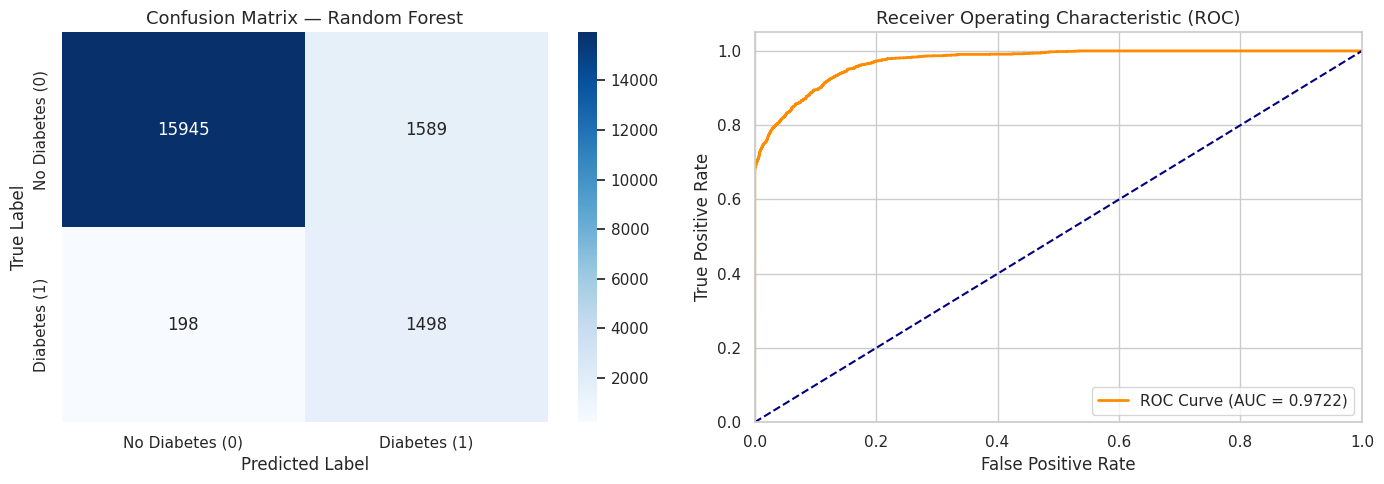

In [24]:
# 6. Confusion Matrix & ROC Curve
best_model_name = "Random Forest"
best_pipeline = trained_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"],
    ax=axes[0],
)
axes[0].set_title(f"Confusion Matrix — {best_model_name}", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc_val:.4f})",
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

###Model Justification

####Random Forest is chosen to be the top performing algorithm since it has the highest ROC-AUC score of 0.9722 along with a relatively good Recall of 88.33%. In a medical diagnostic problem, having high recall is very important in order to avoid any false negative (there are only 198 false negatives among 1,696 observations) since there are risks associated with missing a high-risk individual. Although KNN has higher precision than other algorithms, Random Forest gives the optimal balance of both aspects.